# S07-demo-03 — Утечки через preprocessing: как получить «красивые», но нечестные метрики

Этот ноутбук показывает, что **утечка данных часто рождается не в самой модели, а в подготовке признаков**.

Мы сравним три протокола на одной и той же задаче бинарной классификации:

1. **Honest pipeline** — импутация, масштабирование и отбор признаков обучаются **только на train** внутри `Pipeline`.
2. **Subtle leak** — импутер и scaler обучаются на **всех данных до split**. Это уже ошибка, хотя эффект может быть умеренным.
3. **Severe leak** — отбор признаков `SelectKBest` тоже обучается на **всех данных вместе с target**. Это уже тяжёлая утечка: тест начинает участвовать в выборе признаков.

Главная цель семинара: почувствовать, что **неправильный preprocessing может «нарисовать» улучшение качества там, где его на самом деле нет**.


## 0. Настройки эксперимента, импорты, артефакты

Работаем в том же инженерном стиле, что и в S06:

- фиксируем `RANDOM_STATE`;
- заранее создаём папку `artifacts/`;
- держим один и тот же train/test для всех протоколов;
- параметры модели выбираем **один раз** в честном протоколе, чтобы дальше сравнивать именно влияние утечки.


In [1]:
# Базовые настройки, импорты и папка для артефактов.
from __future__ import annotations

import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
ARTIFACTS_DIR = Path('artifacts')
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.figsize'] = (10, 4)
pd.set_option('display.precision', 4)


In [2]:
# Вспомогательные функции: генерация данных, метрики, сохранение JSON.
def save_json(path: Path, payload: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding='utf-8')


def compute_metrics(y_true: pd.Series, proba: np.ndarray, threshold: float = 0.5) -> dict:
    pred = (proba >= threshold).astype(int)
    return {
        'accuracy': accuracy_score(y_true, pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, pred),
        'f1': f1_score(y_true, pred),
        'roc_auc': roc_auc_score(y_true, proba),
    }


def build_leakage_dataset(n_samples: int = 1800, random_state: int = RANDOM_STATE) -> tuple[pd.DataFrame, pd.Series]:
    # Синтетический табличный датасет, специально удобный для демонстрации утечек.
    # Почему он подходит:
    # - много шумовых признаков: selector может случайно "подглядеть" test;
    # - разные масштабы: появляется естественная потребность в scaling;
    # - пропуски: появляется потребность в imputation;
    # - небольшой шум в метках: задача не становится слишком тривиальной.
    X, y = make_classification(
        n_samples=n_samples,
        n_features=220,
        n_informative=12,
        n_redundant=8,
        n_repeated=0,
        n_clusters_per_class=2,
        class_sep=0.75,
        flip_y=0.05,
        weights=[0.62, 0.38],
        random_state=random_state,
    )
    df = pd.DataFrame(X, columns=[f'f_{i:03d}' for i in range(X.shape[1])])
    y = pd.Series(y, name='target')

    rng = np.random.default_rng(random_state)

    for i, col in enumerate(df.columns):
        if i < 40:
            df[col] *= 0.1
        elif i < 80:
            df[col] *= 3.0
        elif i < 120:
            df[col] *= 20.0

    mcar_mask = rng.random(df.shape) < 0.05
    df = df.mask(mcar_mask)

    return df, y


## 1. Данные и фиксированное разбиение train/test

Сначала готовим данные и **один раз** делаем train/test split.

Это важно: все дальнейшие эксперименты обязаны использовать **одни и те же индексы train и test**, иначе сравнение будет нечестным уже на уровне постановки.


In [3]:
# Генерация датасета и фиксированное разбиение train/test.
X_all, y_all = build_leakage_dataset(n_samples=1800, random_state=RANDOM_STATE)

X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.25,
    stratify=y_all,
    random_state=RANDOM_STATE,
)

print(f'X_all shape   : {X_all.shape}')
print(f'X_train shape : {X_train.shape}')
print(f'X_test shape  : {X_test.shape}')
print(f'Positive class share (train): {y_train.mean():.3f}')
print(f'Positive class share (test) : {y_test.mean():.3f}')


X_all shape   : (1800, 220)
X_train shape : (1350, 220)
X_test shape  : (450, 220)
Positive class share (train): 0.390
Positive class share (test) : 0.389


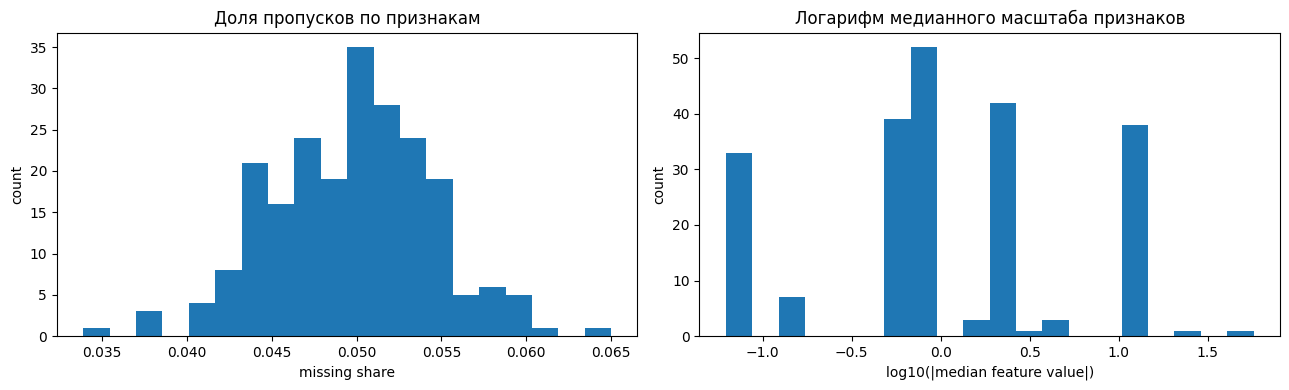

,missing_share,median_abs_value
f_217,0.0650,0.6792
f_184,0.0606,0.7128
f_188,0.0600,0.6684
f_150,0.0600,0.6872
f_050,0.0594,2.0218
f_202,0.0594,0.6881
f_195,0.0589,0.6976
f_115,0.0583,13.5744
f_019,0.0583,0.0671
f_175,0.0578,0.6809


In [4]:
# Быстрая диагностика данных: пропуски и гетерогенность шкал.
missing_share = X_all.isna().mean().sort_values(ascending=False)
scale_proxy = X_all.abs().median(skipna=True).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(missing_share, bins=20)
axes[0].set_title('Доля пропусков по признакам')
axes[0].set_xlabel('missing share')
axes[0].set_ylabel('count')

axes[1].hist(np.log10(scale_proxy.clip(lower=1e-6)), bins=20)
axes[1].set_title('Логарифм медианного масштаба признаков')
axes[1].set_xlabel('log10(|median feature value|)')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()

pd.DataFrame({
    'missing_share': missing_share.head(10),
    'median_abs_value': scale_proxy[missing_share.head(10).index],
})


## 2. Честный протокол: весь preprocessing живёт внутри `Pipeline`

Это эталонный вариант.

Что здесь принципиально правильно:

- импутер, scaler и feature selector обучаются **только на train**;
- подбор `C` делаем через `GridSearchCV` тоже только на train;
- тест трогаем **один раз** — только в самом конце.

Фиксируем `k=40` признаков и подбираем только `C`, чтобы не раздувать эксперимент.


In [5]:
# Честный pipeline и подбор C только на train.
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

honest_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('selector', SelectKBest(score_func=f_classif, k=40)),
        (
            'model',
            LogisticRegression(
                max_iter=3000,
                solver='liblinear',
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

param_grid = {'model__C': [0.1, 0.3, 1.0, 3.0]}

honest_search = GridSearchCV(
    estimator=honest_pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=1,
)

honest_search.fit(X_train, y_train)

best_C = honest_search.best_params_['model__C']
honest_model = honest_search.best_estimator_
honest_test_proba = honest_model.predict_proba(X_test)[:, 1]
honest_metrics = compute_metrics(y_test, honest_test_proba)

print('Best C from honest protocol:', best_C)
print('Best CV ROC-AUC:', round(honest_search.best_score_, 4))
pd.DataFrame([{'protocol': 'honest_pipeline', **honest_metrics}])


Best C from honest protocol: 0.1
Best CV ROC-AUC: 0.7682


,protocol,accuracy,balanced_accuracy,f1,roc_auc
0,honest_pipeline,0.7089,0.6964,0.631,0.7795


## 3. Умеренная утечка: feature selection вне цикла кросс-валидации

Теперь делаем другую типичную ошибку.

Неправильный протокол:

- импутация и масштабирование — **корректны**: обучаются только на `X_train`;
- но `SelectKBest` обучается на **всём `X_train` целиком** — **до** того, как запускается cross-validation;
- значит, при каждом CV-прогоне валидационные образцы уже «подглядели» в статистики feature selector'а.

Результат: **CV-метрика будет завышена**, тогда как тестовая остаётся честной.  
На практике это означает: модель кажется лучше во время разработки, но при финальной проверке или деплое это не подтверждается.

> Тот же механизм убедительно показан в нулевом эксперименте (секция 6):  
> на permuted labels честный pipeline даёт ROC-AUC ≈ 0.53, а selector-before-CV — ≈ 0.63.


In [6]:
# Умеренная утечка: selector fit на полном X_train ДО CV (не внутри Pipeline).

# Imputer и scaler — правильно, только на train.
subtle_imputer = SimpleImputer(strategy='median').fit(X_train)
X_train_si = pd.DataFrame(
    subtle_imputer.transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_si = pd.DataFrame(
    subtle_imputer.transform(X_test), columns=X_test.columns, index=X_test.index
)

subtle_scaler = StandardScaler().fit(X_train_si)
X_train_ss = pd.DataFrame(
    subtle_scaler.transform(X_train_si), columns=X_train.columns, index=X_train.index
)
X_test_ss = pd.DataFrame(
    subtle_scaler.transform(X_test_si), columns=X_test.columns, index=X_test.index
)

# ОШИБКА: selector обучается на полном X_train до разбиения на CV-фолды.
# Валидационные образцы «подглядели» в статистики отбора признаков.
subtle_selector = SelectKBest(score_func=f_classif, k=40).fit(X_train_ss, y_train)
X_train_subtle = subtle_selector.transform(X_train_ss)
X_test_subtle_arr = subtle_selector.transform(X_test_ss)

# CV ROC-AUC будет завышен: selector видел все фолды, включая validation-части.
subtle_cv_roc_auc = float(np.mean(
    cross_val_score(
        LogisticRegression(C=best_C, max_iter=3000, solver='liblinear', random_state=RANDOM_STATE),
        X_train_subtle,
        y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=1,
    )
))

subtle_model = LogisticRegression(
    C=best_C, max_iter=3000, solver='liblinear', random_state=RANDOM_STATE
)
subtle_model.fit(X_train_subtle, y_train)
subtle_test_proba = subtle_model.predict_proba(X_test_subtle_arr)[:, 1]
subtle_metrics = compute_metrics(y_test, subtle_test_proba)

print(f'Честный pipeline  CV ROC-AUC : {honest_search.best_score_:.4f}')
print(f'Subtle leak       CV ROC-AUC : {subtle_cv_roc_auc:.4f}  ← завышен из-за утечки в CV')
pd.DataFrame([{'protocol': 'subtle_leak_selector_before_cv', **subtle_metrics}])


Честный pipeline  CV ROC-AUC : 0.7682
Subtle leak       CV ROC-AUC : 0.7980  ← завышен из-за утечки в CV


,protocol,accuracy,balanced_accuracy,f1,roc_auc
0,subtle_leak_selector_before_cv,0.7089,0.6964,0.631,0.7795


## 4. Тяжёлая утечка: отбор признаков на всех данных вместе с `y`

Это уже действительно опасный вариант.

Неправильный протокол:

- импутируем и масштабируем **все данные**;
- потом делаем `SelectKBest(f_classif)` тоже на **всех данных** и с использованием **всего target**;
- затем учим только логистическую регрессию на train.

Здесь тест начинает участвовать в выборе признаков. Формально у нас всё ещё есть `test split`, но по сути он уже **загрязнён**.


In [7]:
# Тяжёлая утечка: selector видит и X_test, и y_test.
severe_imputer = SimpleImputer(strategy='median').fit(X_all)
X_all_imputed_severe = pd.DataFrame(
    severe_imputer.transform(X_all),
    columns=X_all.columns,
    index=X_all.index,
)

severe_scaler = StandardScaler().fit(X_all_imputed_severe)
X_all_scaled_severe = pd.DataFrame(
    severe_scaler.transform(X_all_imputed_severe),
    columns=X_all.columns,
    index=X_all.index,
)

severe_selector = SelectKBest(score_func=f_classif, k=40).fit(X_all_scaled_severe, y_all)
X_train_severe = severe_selector.transform(X_all_scaled_severe.loc[X_train.index])
X_test_severe = severe_selector.transform(X_all_scaled_severe.loc[X_test.index])

severe_model = LogisticRegression(
    C=best_C,
    max_iter=3000,
    solver='liblinear',
    random_state=RANDOM_STATE,
)
severe_model.fit(X_train_severe, y_train)
severe_test_proba = severe_model.predict_proba(X_test_severe)[:, 1]
severe_metrics = compute_metrics(y_test, severe_test_proba)

pd.DataFrame([{'protocol': 'severe_leak_feature_selection_on_all_data', **severe_metrics}])


,protocol,accuracy,balanced_accuracy,f1,roc_auc
0,severe_leak_feature_selection_on_all_data,0.7267,0.7151,0.6535,0.8006


## 5. Сводное сравнение протоколов

Ниже мы намеренно складываем результаты в одну таблицу.

Интерпретация должна быть такой:

- если у протокола выше метрика, это **ещё не значит**, что он лучше;
- сначала надо проверить, **не нарушен ли сам протокол измерения**;
- утечка часто выглядит как «улучшение», хотя на самом деле это просто загрязнение оценки.

Обратите особое внимание на столбец `cv_roc_auc`:

- у **честного pipeline** CV-score близок к test-score — всё консистентно;
- у **«умеренной» утечки** CV-score **завышен** относительно test-score — модель обманывает сама себя во время подбора параметров;
- у **«тяжёлой» утечки** завышен уже сам **test-score** — деплой даст разочарование.


In [8]:
# Таблица сравнения трёх протоколов.
results_df = pd.DataFrame([
    {
        'protocol': 'honest_pipeline',
        'validity': 'valid',
        'leak_level': 'none',
        'cv_roc_auc': round(honest_search.best_score_, 4),
        **honest_metrics,
    },
    {
        'protocol': 'subtle_leak_selector_before_cv',
        'validity': 'invalid',
        'leak_level': 'moderate (CV inflated)',
        'cv_roc_auc': round(subtle_cv_roc_auc, 4),
        **subtle_metrics,
    },
    {
        'protocol': 'severe_leak_feature_selection_on_all_data',
        'validity': 'invalid',
        'leak_level': 'severe (test inflated)',
        'cv_roc_auc': float('nan'),
        **severe_metrics,
    },
]).sort_values('roc_auc', ascending=False).reset_index(drop=True)

results_df


,protocol,validity,leak_level,cv_roc_auc,accuracy,balanced_accuracy,f1,roc_auc
0,severe_leak_feature_selection_on_all_data,invalid,severe (test inflated),NaN,0.7267,0.7151,0.6535,0.8006
1,honest_pipeline,valid,none,0.7682,0.7089,0.6964,0.6310,0.7795
2,subtle_leak_selector_before_cv,invalid,moderate (CV inflated),0.7980,0.7089,0.6964,0.6310,0.7795


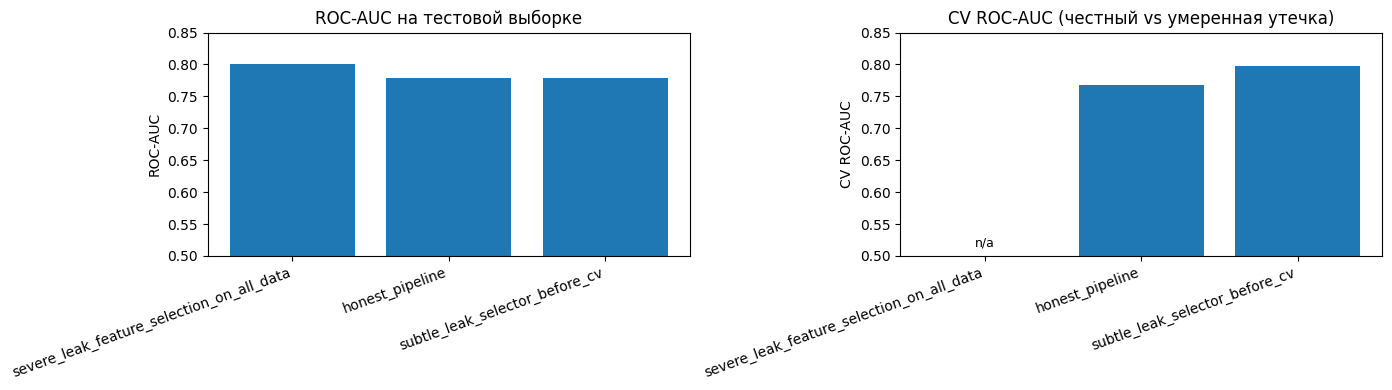

In [9]:
# Визуализация: ROC-AUC на тесте vs ROC-AUC в CV для каждого протокола.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

short_labels = ['honest', 'subtle\n(selector\nbefore CV)', 'severe\n(selector\non all data)']

axes[0].bar(range(len(results_df)), results_df['roc_auc'])
axes[0].set_title('ROC-AUC на тестовой выборке')
axes[0].set_ylabel('ROC-AUC')
axes[0].set_xticks(range(len(results_df)))
axes[0].set_xticklabels(results_df['protocol'], rotation=20, ha='right')
axes[0].set_ylim(0.5, max(0.85, results_df['roc_auc'].max() + 0.03))

# CV ROC-AUC: only honest and subtle have it
cv_vals = results_df['cv_roc_auc'].fillna(0)
bars = axes[1].bar(range(len(results_df)), cv_vals)
axes[1].set_title('CV ROC-AUC (честный vs умеренная утечка)')
axes[1].set_ylabel('CV ROC-AUC')
axes[1].set_xticks(range(len(results_df)))
axes[1].set_xticklabels(results_df['protocol'], rotation=20, ha='right')
axes[1].set_ylim(0.5, max(0.85, cv_vals.max() + 0.03))
# mark the severe bar as "n/a"
severe_idx = results_df.index[results_df['protocol'].str.contains('severe')].tolist()
for idx in severe_idx:
    axes[1].text(idx, 0.51, 'n/a', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


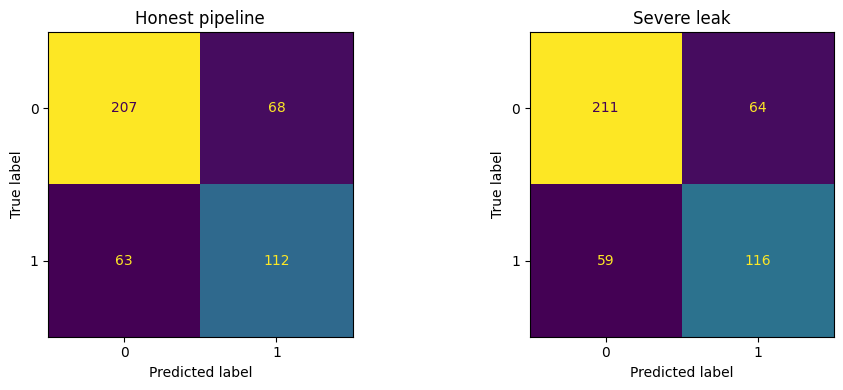

In [10]:
# Confusion matrix: честный протокол vs тяжёлая утечка.
honest_pred = (honest_test_proba >= 0.5).astype(int)
severe_pred = (severe_test_proba >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_test, honest_pred, ax=axes[0], colorbar=False)
axes[0].set_title('Honest pipeline')

ConfusionMatrixDisplay.from_predictions(y_test, severe_pred, ax=axes[1], colorbar=False)
axes[1].set_title('Severe leak')

plt.tight_layout()
plt.show()


## 6. Нулевой эксперимент: можно ли «найти сигнал» там, где его нет?

Это самый убедительный фрагмент ноутбука.

Мы **перемешаем метки** на train. После этого в данных больше нет реальной связи между `X` и `y`.

Ожидаемое поведение:

- честный pipeline должен дать ROC-AUC около **0.5**;
- если после утечки качество заметно выше 0.5, значит мы научились не задаче, а **ошибке протокола**.


In [11]:
# Нулевой эксперимент на permuted labels.
rng = np.random.default_rng(RANDOM_STATE)
y_train_permuted = pd.Series(
    rng.permutation(y_train.to_numpy()),
    index=y_train.index,
    name='target_permuted',
)

null_honest_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('selector', SelectKBest(score_func=f_classif, k=40)),
        (
            'model',
            LogisticRegression(
                C=best_C,
                max_iter=3000,
                solver='liblinear',
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

null_honest_scores = cross_val_score(
    estimator=null_honest_pipeline,
    X=X_train,
    y=y_train_permuted,
    cv=cv,
    scoring='roc_auc',
    n_jobs=1,
)

null_imputer = SimpleImputer(strategy='median').fit(X_train)
X_train_null_imputed = pd.DataFrame(
    null_imputer.transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
null_scaler = StandardScaler().fit(X_train_null_imputed)
X_train_null_scaled = pd.DataFrame(
    null_scaler.transform(X_train_null_imputed),
    columns=X_train.columns,
    index=X_train.index,
)
null_selector = SelectKBest(score_func=f_classif, k=40).fit(X_train_null_scaled, y_train_permuted)
X_train_null_selected = null_selector.transform(X_train_null_scaled)

null_leaky_scores = cross_val_score(
    estimator=LogisticRegression(
        C=best_C,
        max_iter=3000,
        solver='liblinear',
        random_state=RANDOM_STATE,
    ),
    X=X_train_null_selected,
    y=y_train_permuted,
    cv=cv,
    scoring='roc_auc',
    n_jobs=1,
)

null_results_df = pd.DataFrame(
    {
        'fold': np.arange(1, len(null_honest_scores) + 1),
        'honest_pipeline': null_honest_scores,
        'leaky_global_selection': null_leaky_scores,
    }
)

null_results_df


,fold,honest_pipeline,leaky_global_selection
0,1,0.5558,0.6023
1,2,0.5648,0.6827
2,3,0.5181,0.6394
3,4,0.4981,0.6031


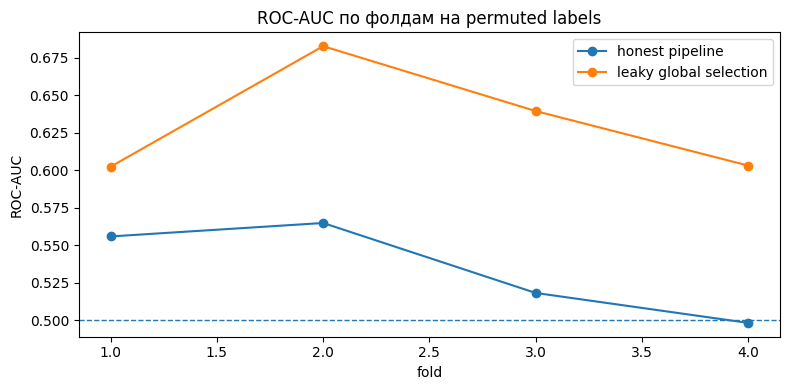

,experiment,mean_roc_auc,std_roc_auc
0,honest_pipeline_on_permuted_labels,0.5342,0.0272
1,leaky_global_selection_on_permuted_labels,0.6319,0.0329


In [12]:
# Визуализация нулевого эксперимента.
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(null_results_df['fold'], null_results_df['honest_pipeline'], marker='o', label='honest pipeline')
ax.plot(null_results_df['fold'], null_results_df['leaky_global_selection'], marker='o', label='leaky global selection')
ax.axhline(0.5, linestyle='--', linewidth=1)
ax.set_title('ROC-AUC по фолдам на permuted labels')
ax.set_xlabel('fold')
ax.set_ylabel('ROC-AUC')
ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame(
    [
        {
            'experiment': 'honest_pipeline_on_permuted_labels',
            'mean_roc_auc': float(np.mean(null_honest_scores)),
            'std_roc_auc': float(np.std(null_honest_scores)),
        },
        {
            'experiment': 'leaky_global_selection_on_permuted_labels',
            'mean_roc_auc': float(np.mean(null_leaky_scores)),
            'std_roc_auc': float(np.std(null_leaky_scores)),
        },
    ]
)


## 7. Какие признаки попали в честный и в «загрязнённый» отбор

Здесь полезно посмотреть не только на цифры метрик, но и на сами выбранные признаки.

Если selector обучался на train и на всех данных, он может выбрать **разные наборы признаков**. В протоколе с утечкой часть решения уже «подстроена» под test.


In [13]:
# Сравнение наборов выбранных признаков: честный vs тяжёлая утечка.
#
# Примечание: honest_model.best_estimator_ после GridSearchCV обучается на полном X_train.
# Subtle_selector тоже обучался на полном X_train.
# Поэтому их наборы признаков совпадают на 100% — это нормально и ожидаемо.
# Ключевое отличие subtle_leak — в завышенной CV-метрике, а не в другом наборе признаков.
honest_selector = honest_model.named_steps['selector']
honest_selected_features = X_train.columns[honest_selector.get_support()].tolist()
severe_selected_features = X_all.columns[severe_selector.get_support()].tolist()
subtle_selected_features = X_train_ss.columns[subtle_selector.get_support()].tolist()

overlap_honest_severe = sorted(set(honest_selected_features) & set(severe_selected_features))
selected_only_honest = sorted(set(honest_selected_features) - set(severe_selected_features))
selected_only_severe = sorted(set(severe_selected_features) - set(honest_selected_features))
subtle_honest_overlap_n = len(set(honest_selected_features) & set(subtle_selected_features))

selection_audit = {
    'n_honest_selected': len(honest_selected_features),
    'n_severe_selected': len(severe_selected_features),
    'n_overlap_honest_severe': len(overlap_honest_severe),
    'overlap_share_honest_severe': round(len(overlap_honest_severe) / len(honest_selected_features), 3),
    'n_overlap_honest_subtle': subtle_honest_overlap_n,
    'overlap_share_honest_subtle': round(subtle_honest_overlap_n / len(honest_selected_features), 3),
    'selected_only_honest_preview': selected_only_honest[:10],
    'selected_only_severe_preview': selected_only_severe[:10],
}

pd.DataFrame([selection_audit])


,n_honest_selected,n_severe_selected,n_overlap_honest_severe,overlap_share_honest_severe,n_overlap_honest_subtle,overlap_share_honest_subtle,selected_only_honest_preview,selected_only_severe_preview
0,40,40,30,0.75,40,1.0,"[f_012, f_032, f_070, f_073, f_124, f_147, f_1...","[f_030, f_031, f_053, f_066, f_081, f_084, f_0..."


## 8. Сохраняем артефакты

Сохраним всё, что может пригодиться для разбора после семинара:

- таблицу сравнения протоколов;
- результаты нулевого эксперимента;
- честный pipeline целиком;
- bundle тяжёлой утечки (чтобы потом посмотреть, из чего он состоял);
- JSON с ключевыми выводами.


In [14]:
# Сохранение артефактов.
results_path = ARTIFACTS_DIR / 's07_demo_03_protocol_comparison.csv'
null_results_path = ARTIFACTS_DIR / 's07_demo_03_null_experiment.csv'
honest_model_path = ARTIFACTS_DIR / 's07_demo_03_honest_pipeline.joblib'
severe_bundle_path = ARTIFACTS_DIR / 's07_demo_03_severe_leak_bundle.joblib'
meta_path = ARTIFACTS_DIR / 's07_demo_03_meta.json'

results_df.to_csv(results_path, index=False)
null_results_df.to_csv(null_results_path, index=False)
joblib.dump(honest_model, honest_model_path)
joblib.dump(
    {
        'imputer': severe_imputer,
        'scaler': severe_scaler,
        'selector': severe_selector,
        'model': severe_model,
        'description': 'INVALID example: preprocessing fitted on full dataset including test labels',
    },
    severe_bundle_path,
)

save_json(
    meta_path,
    {
        'seminar': 'S07',
        'notebook': 'S07_demo_03_preprocessing_leakage',
        'random_state': RANDOM_STATE,
        'best_C_from_honest_protocol': best_C,
        'protocol_summary': results_df.to_dict(orient='records'),
        'null_experiment_summary': [
            {
                'experiment': 'honest_pipeline_on_permuted_labels',
                'mean_roc_auc': float(np.mean(null_honest_scores)),
                'std_roc_auc': float(np.std(null_honest_scores)),
            },
            {
                'experiment': 'leaky_global_selection_on_permuted_labels',
                'mean_roc_auc': float(np.mean(null_leaky_scores)),
                'std_roc_auc': float(np.std(null_leaky_scores)),
            },
        ],
        'selection_audit': selection_audit,
    },
)

print('Saved:')
print(' -', results_path)
print(' -', null_results_path)
print(' -', honest_model_path)
print(' -', severe_bundle_path)
print(' -', meta_path)


Saved:
 - artifacts\s07_demo_03_protocol_comparison.csv
 - artifacts\s07_demo_03_null_experiment.csv
 - artifacts\s07_demo_03_honest_pipeline.joblib
 - artifacts\s07_demo_03_severe_leak_bundle.joblib
 - artifacts\s07_demo_03_meta.json


## 9. Итоги

Из этого ноутбука нужно вынести несколько инженерных правил.

1. **Preprocessing — это часть модели.** Его нельзя делать «в стороне» от train/test протокола.
2. **Умеренная утечка:** если шаг с `fit` (даже `SelectKBest`) обучается на полном `X_train` до CV — это уже утечка. CV-метрика будет завышена, хотя тест может казаться нормальным. Именно это вводит в заблуждение во время разработки.
3. **Тяжёлая утечка:** супервизируемый preprocessing вне `Pipeline` на всех данных включая тест прямо загрязняет тестовую метрику. Модель кажется лучше в прода, пока не попадёт в прод.
4. **Нулевой эксперимент** — мощный инструмент: если на permuted labels качество заметно выше 0.5, протокол сломан.
5. **Полезная диагностика:** сравнивай CV-score и test-score. У честного pipeline они должны быть близки. Если CV >> test — утечка в цикле валидации.
6. Хорошая практика по умолчанию: всё, что имеет `fit`, должно жить внутри `Pipeline` и обучаться только на train / train-fold.

Именно это и есть главная мысль S07: модель можно «убить» или искусственно «улучшить» ещё до этапа обучения — на уровне признаков и подготовки данных.
